In [ ]:

from ultralytics import YOLO
from roboflow import Roboflow

# --- ÉTAPE 1 : CODE ROBOFLOW ---
rf = Roboflow(api_key="D0ZhK3HFkADcEkjH3vVD")
project = rf.workspace("aroles-workspace").project("parking-control-school-paepn")
version = project.version(2)
dataset = version.download("yolov8")

# --- ÉTAPE 2 : CHARGEMENT DU MODÈLE ---
model = YOLO('yolov8n.pt')

# --- ÉTAPE 3 : ENTRAÎNEMENT ---
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    plots=True
)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Parking-Control-School-2 in yolov8:: 100%|██████████| 594/594 [00:00<00:00, 2175.85it/s]


Ultralytics 8.4.21  Python-3.9.25 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\Parking-Control-School-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000193A7AF3580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480


image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\206.jpg: 480x640 2 plaques, 48.5ms
Speed: 4.2ms preprocess, 48.5ms inference, 2.6ms postprocess per image at shape (1, 3, 480, 640)


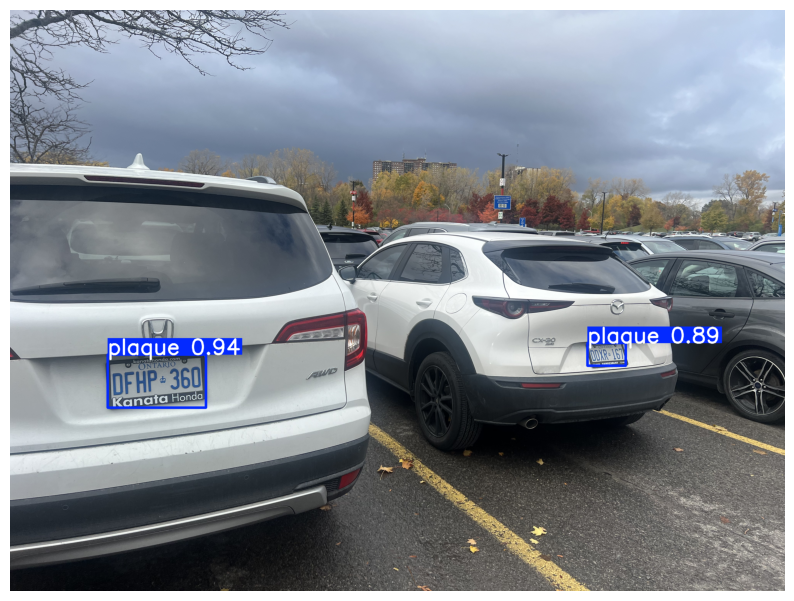

In [4]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Charger le modèle
model = YOLO("best.pt")

# 2. Lancer la détection
image_path =  "D:\\IA EN INFORMATIQUE\\ETAPE 4\\PROJET CAPSTONE EN IA\\images\\206.jpg"
results = model.predict(source=image_path, conf=0.5)

# 3. Affichage direct dans le Notebook
for r in results:
    img_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB) # YOLO utilise BGR, Matplotlib veut du RGB
    plt.figure(figsize=(10,10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4213.jpg: 640x480 1 plaque, 21.3ms
Speed: 3.2ms preprocess, 21.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


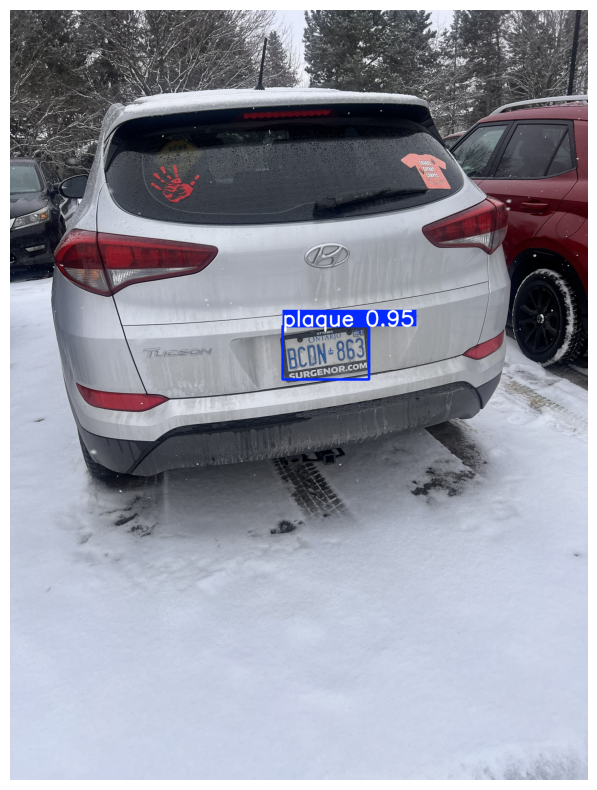

In [18]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Charger le modèle
model = YOLO("best.pt")

# 2. Lancer la détection
image_path =  "D:\\IA EN INFORMATIQUE\\ETAPE 4\\PROJET CAPSTONE EN IA\\new\\IMG_4213.jpg"
results = model.predict(source=image_path, conf=0.5)

# 3. Affichage direct dans le Notebook
for r in results:
    img_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB) # YOLO utilise BGR, Matplotlib veut du RGB
    plt.figure(figsize=(10,10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\9.jpg: 640x480 2 plaques, 15.5ms
Speed: 3.3ms preprocess, 15.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Numéro détecté : QUEBEC (Confiance: 1.00)


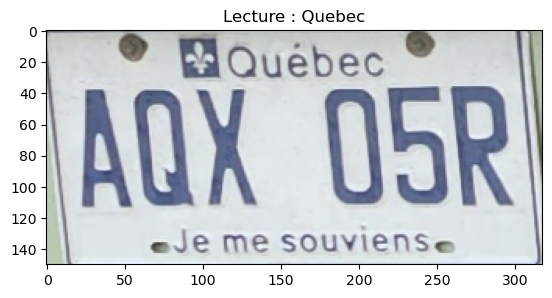

Numéro détecté : A_X   O5RL (Confiance: 0.12)


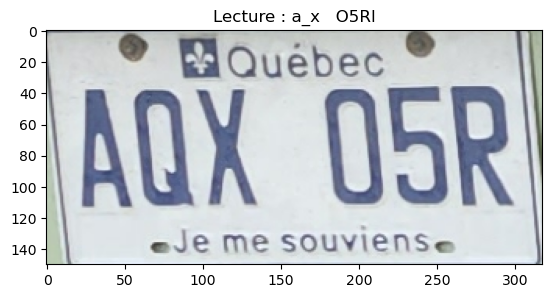

Numéro détecté : JE ME SOUVIENS_ (Confiance: 0.88)


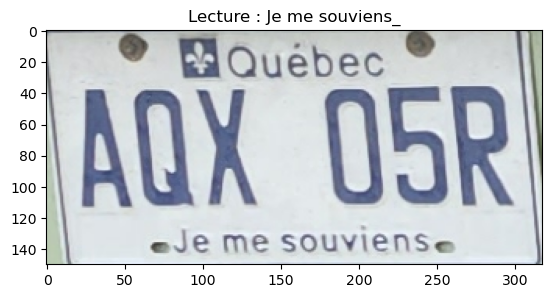

In [ ]:
import easyocr
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Charger le modèle et l'OCR (une seule fois au début)
model = YOLO("best.pt")
reader = easyocr.Reader(['en']) # 'en' ou 'fr' pour les plaques

def detecter_et_lire(image_path):
    img = cv2.imread(image_path)
    results = model(image_path)
    
    for r in results:
        boxes = r.boxes
        for box in boxes:
            # Coordonnées du rectangle
            x1, y1, x2, y2 = box.xyxy[0]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            
            # Découpage de la plaque
            plaque_crop = img[y1:y2, x1:x2]
            
            # Lecture du texte
            result_ocr = reader.readtext(plaque_crop)
            
            for (bbox, text, prob) in result_ocr:
                print(f"Numéro détecté : {text.upper()} (Confiance: {prob:.2f})")
                
                # Optionnel : Afficher le crop pour vérifier
                plt.imshow(cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2RGB))
                plt.title(f"Lecture : {text}")
                plt.show()

# Test
path = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\9.jpg"
detecter_et_lire(path)


image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\7.jpg: 640x480 1 plaque, 14.1ms
Speed: 4.9ms preprocess, 14.1ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)
 Plaque localisée mais aucun numéro valide n'a pu être lu.


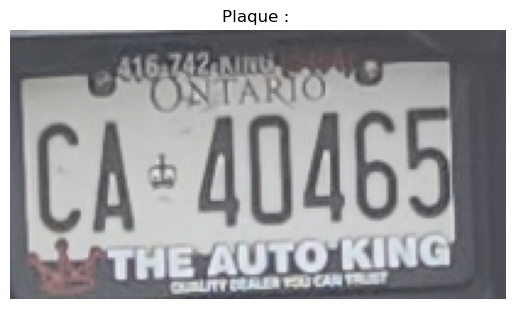

In [ ]:
import easyocr
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT DES MODÈLES ---
# Modèle YOLO entraîné pour localiser la plaque
model = YOLO("best.pt")

# Le lecteur EasyOCR pour lire les caractères
reader = easyocr.Reader(['en'])

# Liste des textes à ignorer (provinces et slogans)
MOTS_IGNORER = ["ONTARIO", "QUEBEC", "YOURSTODISCOVER", "JEMESOUVIENS", "CANADA"]

def tester_ocr_sur_image(image_path):
    # Charger l'image
    img = cv2.imread(image_path)
    if img is None:
        print("Erreur : Image introuvable.")
        return

    # Étape 1 : Localisation avec YOLO
    results = model(image_path)
    
    for r in results:
        for box in r.boxes:
            # Récupérer les coordonnées du rectangle (x1, y1, x2, y2)
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Étape 2 : Découpage (Crop) de la plaque
            plaque_crop = img[y1:y2, x1:x2]
            
            # Étape 3 : Lecture avec EasyOCR
            resultat_lecture = reader.readtext(plaque_crop)
            
            plaque_finale = ""
            max_conf = 0
            
            for (bbox, text, prob) in resultat_lecture:
                # Nettoyage : Majuscules, retrait des espaces et tirets
                text_clean = text.upper().replace(" ", "").replace("-", "").replace(".", "")
                
                # Étape 4 : Filtrage intelligent
                # On ignore les mots de la liste noire et les textes trop courts (< 4 caractères)
                if prob > 0.4 and len(text_clean) >= 4 and text_clean not in MOTS_IGNORER:
                    if prob > max_conf:
                        max_conf = prob
                        plaque_finale = text_clean
            
            # --- AFFICHAGE DES RÉSULTATS ---
            if plaque_finale:
                print(f" NUMÉRO DÉTECTÉ : {plaque_finale} (Confiance: {max_conf:.2f})")
                
                # Visualisation du crop
                img_display = cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2RGB)
                plt.imshow(img_display)
                plt.title(f"Plaque : {plaque_finale}")
                plt.axis('off')
                plt.show()
            else:
                print(" Plaque localisée mais aucun numéro valide n'a pu être lu.")
                img_display = cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2RGB)
                plt.imshow(img_display)
                plt.title(f"Plaque : {plaque_finale}")
                plt.axis('off')
                plt.show()

# --- LANCEMENT DU TEST ---
# Remplace par le chemin de ton image 9.jpg
mon_image = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\7.jpg"
tester_ocr_sur_image(mon_image)

 NUMÉRO DÉTECTÉ : CA:40465 (Score: 0.76)


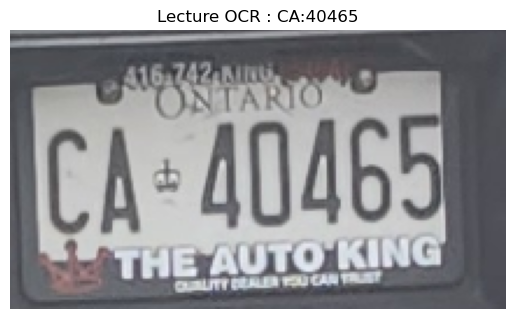

In [1]:
import easyocr
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT DES MODÈLES ---
# Chargement modèle YOLO entraîné 
model = YOLO("best.pt")

# Initialiser le lecteur EasyOCR (Anglais uniquement pour les plaques standards)
# Note : Il téléchargera les modèles lors de la première exécution
reader = easyocr.Reader(['en'])

# Liste noire des mots souvent lus sur les plaques canadiennes qu'on veut ignorer
MOTS_IGNORER = ["ONTARIO", "QUEBEC", "YOURSTODISCOVER", "JEMESOUVIENS", "CANADA"]

def extraire_texte_plaque(image_path):
    """
    Détecte la plaque, découpe l'image et extrait le texte filtré.
    """
    # Chargement de l'image via OpenCV
    img = cv2.imread(image_path)
    if img is None:
        print(f"Erreur : Impossible de lire l'image à l'emplacement {image_path}")
        return

    # Étape 1 : Détection de l'emplacement de la plaque avec YOLO
    # conf=0.5 permet de ne garder que les détections solides
    results = model.predict(source=image_path, conf=0.5, verbose=False)
    
    found_any = False

    for r in results:
        for box in r.boxes:
            found_any = True
            # Récupérer les coordonnées du rectangle (x1, y1, x2, y2)
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # Étape 2 : Découpage (Crop) de la zone détectée
            # On ajoute une petite marge de 5 pixels pour ne pas couper les caractères au bord
            plaque_crop = img[max(0, y1-5):y2+5, max(0, x1-5):x2+5]
            
            # Étape 3 : Lecture du texte par EasyOCR
            resultats_ocr = reader.readtext(plaque_crop)
            
            plaque_finale = ""
            meilleure_confiance = 0
            
            # Étape 4 : Analyse et Filtrage des résultats OCR
            for (bbox, text, prob) in resultats_ocr:
                # Nettoyage : Majuscules, suppression des espaces, tirets et points
                text_propre = text.upper().replace(" ", "").replace("-", "").replace(".", "")
                
                # Critères de validation :
                # - Confiance correcte (> 30%)
                # - Longueur minimum (4 caractères pour une plaque)
                # - Pas un mot de la liste noire (Province)
                if prob > 0.3 and len(text_propre) >= 4 and text_propre not in MOTS_IGNORER:
                    if prob > meilleure_confiance:
                        meilleure_confiance = prob
                        plaque_finale = text_propre
            
            # --- AFFICHAGE DES RÉSULTATS ---
            if plaque_finale:
                print(f" NUMÉRO DÉTECTÉ : {plaque_finale} (Score: {meilleure_confiance:.2f})")
                
                # Visualisation du résultat
                img_rgb = cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2RGB)
                plt.imshow(img_rgb)
                plt.title(f"Lecture OCR : {plaque_finale}")
                plt.axis('off')
                plt.show()
            else:
                print(" Plaque localisée, mais le texte est illisible ou filtré.")
                img_rgb = cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2RGB)
                plt.imshow(img_rgb)
                plt.title(f"Lecture OCR : {plaque_finale}")
                plt.axis('off')
                plt.show()

    if not found_any:
        print("❌ Aucune plaque détectée sur cette image.")

# --- ZONE DE TEST ---
chemin_image = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\7.jpg"
extraire_texte_plaque(chemin_image)

In [ ]:
# Juste pour voir ce que l'OCR détecte réellement
reader = easyocr.Reader(['en'], gpu=True)

img = cv2.imread(r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\89.jpeg")

# Lire toute l'image directement
resultats = reader.readtext(img)

print("Tous les textes détectés :")
for (bbox, texte, conf) in resultats:
    print(f"  → '{texte}'  (confiance: {conf:.2f})")

Tous les textes détectés :
  → 'ONTARIO'  (confiance: 0.73)
  → 'DHHK* 062'  (confiance: 0.17)
  → 'YOURS T0 DISCOVER'  (confiance: 0.79)
  → 'QUTLANDER'  (confiance: 0.70)
  → 'Ewa'  (confiance: 0.12)
  → 'MITSUBISHI'  (confiance: 0.97)



image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4201.jpg: 640x480 2 plaques, 10.6ms
Speed: 2.8ms preprocess, 10.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
PLAQUE EXTRAITE : LLE3KPB


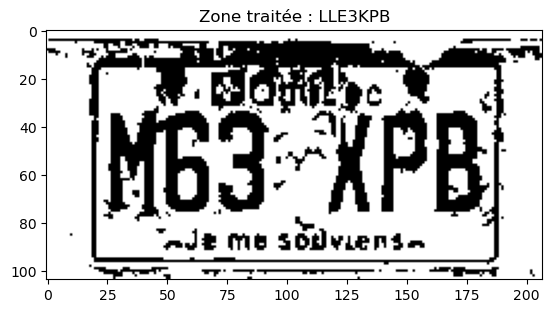

 Échec de lecture sur cette plaque.


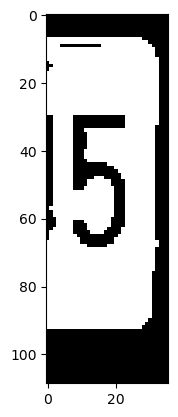

In [24]:
import easyocr
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Configuration
model = YOLO("best.pt")
reader = easyocr.Reader(['en'])

# Liste noire des mots à bannir totalement
LISTE_NOIRE = ["QUEBEC", "ONTARIO", "CANADA", "JEMESOUVIENS", "YOURSTODISCOVER"]

import re

def detecter_et_lire_final(image_path):
    img = cv2.imread(image_path)
    results = model(image_path)
    
    for r in results:
        for box in r.boxes:
            # 1. Récupérer les coordonnées
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            # --- ASTUCE A : Agrandir la zone de 10% pour mieux lire les bords ---
            h, w = y2 - y1, x2 - x1
            y1, y2 = max(0, y1 - int(h*0.1)), min(img.shape[0], y2 + int(h*0.1))
            x1, x2 = max(0, x1 - int(w*0.1)), min(img.shape[1], x2 + int(w*0.1))
            
            plaque_crop = img[y1:y2, x1:x2]
            
            # --- ASTUCE B : Prétraitement (Gris + Contraste) ---
            gray = cv2.cvtColor(plaque_crop, cv2.COLOR_BGR2GRAY)
            # On rend l'image plus "nette" pour l'OCR
            plaque_prete = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

            # 2. Lecture OCR sur l'image améliorée
            result_ocr = reader.readtext(plaque_prete) # ou utiliser 'plaque_crop' si c'est pire
            
            candidats = []
            for (bbox, text, prob) in result_ocr:
                # NETTOYAGE : On ne garde que A-Z et 0-9 (on vire les parenthèses, tirets, symboles)
                t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
                
                # Critères : pas une province, min 4 caractères, contient un chiffre
                if t_clean not in LISTE_NOIRE and len(t_clean) >= 4:
                    if any(char.isdigit() for char in t_clean):
                        candidats.append((t_clean, prob))
            
            if candidats:
                candidats.sort(key=lambda x: x[1], reverse=True)
                plaque_finale = candidats[0][0]
                print(f"PLAQUE EXTRAITE : {plaque_finale}")
                
                plt.imshow(plaque_prete, cmap='gray')
                plt.title(f"Zone traitée : {plaque_finale}")
                plt.show()
            else:
                print(" Échec de lecture sur cette plaque.")
                plt.imshow(plaque_prete, cmap='gray')
                plt.show()

# Test
#detecter_et_lire_final(r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\89.jpeg")
detecter_et_lire_final(r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4201.jpg")



image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4214.jpg: 640x480 1 plaque, 14.6ms
Speed: 3.1ms preprocess, 14.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
 Échec de lecture.


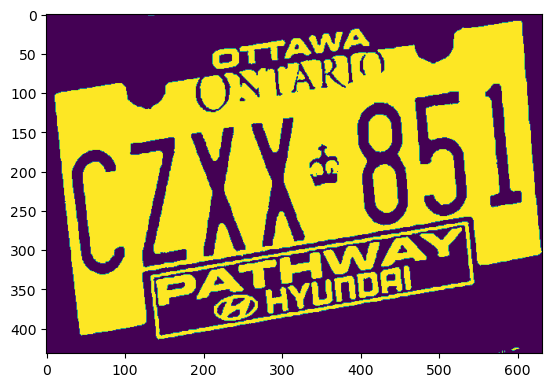

In [7]:
import easyocr
import cv2
import re
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 1. Init
model = YOLO("best.pt")
reader = easyocr.Reader(['en'])
LISTE_NOIRE = ["QUEBEC", "ONTARIO", "CANADA", "JEMESOUVIENS", "YOURSTODISCOVER"]

def ameliorer_image(img_crop):
    # Conversion en niveaux de gris
    gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    # Agrandissement (x2) pour que les lettres soient plus nettes
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    # Filtre pour enlever le bruit
    gray = cv2.bilateralFilter(gray, 11, 17, 17)
    # Binarisation (Noir et Blanc pur)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

def detecter_et_lire_final(image_path):
    img = cv2.imread(image_path)
    results = model(image_path)
    
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            # On prend une marge de 5% autour de la plaque
            h, w = y2 - y1, x2 - x1
            y1, y2 = max(0, y1 - 5), min(img.shape[0], y2 + 5)
            x1, x2 = max(0, x1 - 5), min(img.shape[1], x2 + 5)
            
            plaque_crop = img[y1:y2, x1:x2]
            
            # --- PRÉTRAITEMENT MAGIQUE ---
            plaque_prete = ameliorer_image(plaque_crop)
            
            # Lecture OCR
            result_ocr = reader.readtext(plaque_prete)
            
            candidats = []
            for (bbox, text, prob) in result_ocr:
                t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
                if t_clean not in LISTE_NOIRE and len(t_clean) >= 4:
                    if any(char.isdigit() for char in t_clean):
                        candidats.append((t_clean, prob))
            
            if candidats:
                candidats.sort(key=lambda x: x[1], reverse=True)
                print(f" PLAQUE DÉTECTÉE : {candidats[0][0]} (Confiance: {candidats[0][1]:.2f})")
                plt.imshow(plaque_prete, cmap='gray')
                plt.title(f"Lecture : {candidats[0][0]}")
                plt.show()
            else:
                print(" Échec de lecture.")
                plt.imshow(plaque_prete)
                plt.show()

# TEST
path = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4214.jpg"
detecter_et_lire_final(path)


In [45]:
# Juste pour voir ce que l'OCR détecte réellement
reader = easyocr.Reader(['en'], gpu=True)

img = cv2.imread(r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\new\IMG_4198.jpg")

# Lire toute l'image directement
resultats = reader.readtext(img)

print("Tous les textes détectés :")
for (bbox, texte, conf) in resultats:
    print(f"  → '{texte}'  (confiance: {conf:.2f})")

Tous les textes détectés :
  → 'ONTARIO'  (confiance: 0.73)
  → 'DHHK* 062'  (confiance: 0.17)
  → 'YOURS T0 DISCOVER'  (confiance: 0.79)
  → 'QUTLANDER'  (confiance: 0.70)
  → 'Ewa'  (confiance: 0.12)
  → 'MITSUBISHI'  (confiance: 0.97)


In [5]:
import mlflow
import cv2
import re
import easyocr
from ultralytics import YOLO

# 1. Démarrer une session MLflow
mlflow.set_experiment("Parking_Control_System")

with mlflow.start_run(run_name="Test_Detection_OCR_V1"):
    # Paramètres à enregistrer
    mlflow.log_param("model_type", "YOLOv8n")
    mlflow.log_param("ocr_engine", "EasyOCR")
    
    # Chargement
    model = YOLO("best.pt")
    reader = easyocr.Reader(['en'])
    image_path = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\9.jpg"
    
    # Détection
    results = model.predict(image_path, conf=0.5)
    
    plaque_trouvee = False
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            crop = cv2.imread(image_path)[y1:y2, x1:x2]
            
            # Lecture OCR avec filtrage
            ocr_res = reader.readtext(crop)
            for (_, text, prob) in ocr_res:
                t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
                if len(t_clean) >= 4 and any(c.isdigit() for c in t_clean):
                    if t_clean not in ["QUEBEC", "ONTARIO"]:
                        print(f" Plaque reconnue : {t_clean}")
                        # Enregistrer le résultat dans MLflow
                        mlflow.log_metric("ocr_confidence", prob)
                        mlflow.set_tag("detected_plate", t_clean)
                        plaque_trouvee = True

    if not plaque_trouvee:
        mlflow.set_tag("status", "Pas de plaque détectée")

print(" Expérience enregistrée dans MLflow !")


image 1/1 D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\images\9.jpg: 640x480 1 plaque, 13.2ms
Speed: 2.9ms preprocess, 13.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
 Plaque reconnue : AXO5RL
 Expérience enregistrée dans MLflow !


In [2]:
import mlflow

# Démarrer MLflow avec un nom d'expérience
mlflow.set_experiment("Parking_Control_System")

# Commencer une nouvelle run
mlflow.start_run(run_name="Parking_Detection_Analysis")

# Enregistrer les paramètres de configuration
mlflow.log_param("seuil_confiance_ocr", SEUIL_CONFIANCE_OCR)
mlflow.log_param("nombre_abonnes", len(BASE_ABONNES))
mlflow.log_param("modele", "YOLOv8n")
mlflow.log_param("ocr_engine", "EasyOCR")

# Enregistrer les métriques actuelles
mlflow.log_metric("plaques_detectees", len(set(memoire_plaques)))
mlflow.log_metric("plaque_stable_actuelle", 1 if plaque_stable in BASE_ABONNES else 0)

print(" MLflow démarré avec succès!")
print(f"Expérience: Parking_Control_System")
print(f"Run: Parking_Detection_Analysis")

 MLflow démarré avec succès!
Expérience: Parking_Control_System
Run: Parking_Detection_Analysis


In [ ]:
import cv2
import re
import easyocr
import mlflow
from ultralytics import YOLO

# 1. Configuration
model = YOLO("best.pt")
reader = easyocr.Reader(['en'])
video_path = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\videos\IMG_4217.MOV"
cap = cv2.VideoCapture(video_path)

# Paramètres de filtrage
LISTE_NOIRE = ["QUEBEC", "ONTARIO", "CANADA"]
derniere_plaque_lue = ""
compteur_frames = 0

mlflow.set_experiment("Parking_Control_Video_Tests")

with mlflow.start_run(run_name="Video_Test_Sequence_1"):
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        compteur_frames += 1
        # OPTIMISATION : On n'analyse qu'une image sur 5 pour garder de la fluidité
        if compteur_frames % 5 != 0:
            continue

        # Détection avec YOLO
        results = model.predict(frame, conf=0.6, verbose=False)
        
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plaque_crop = frame[y1:y2, x1:x2]
                
                # Lecture OCR
                result_ocr = reader.readtext(plaque_crop)
                
                for (_, text, prob) in result_ocr:
                    t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
                    
                    # Logique de validation
                    if len(t_clean) >= 4 and any(c.isdigit() for c in t_clean):
                        if t_clean not in LISTE_NOIRE and t_clean != derniere_plaque_lue:
                            print(f" Véhicule détecté : {t_clean} (Confiance: {prob:.2f})")
                            derniere_plaque_lue = t_clean
                            
                            # Enregistrement dans MLflow
                            mlflow.log_text(t_clean, f"plates/frame_{compteur_frames}.txt")
                            
                            # Dessiner sur la vidéo pour le feedback visuel
                            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                            cv2.putText(frame, t_clean, (x1, y1 - 10), 
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        # Affichage de la vidéo en direct
        cv2.imshow("Test Video Parking", frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

 Véhicule détecté : IZZ0VREL (Confiance: 0.26)
 Véhicule détecté : IZ20VREI (Confiance: 0.16)
 Véhicule détecté : IZ20VRE (Confiance: 0.11)
 Véhicule détecté : Z20VRE (Confiance: 0.16)
 Véhicule détecté : 220VRE (Confiance: 0.17)
 Véhicule détecté : 220VREL (Confiance: 0.23)
 Véhicule détecté : 220VRE (Confiance: 0.34)
 Véhicule détecté : Z20VRE (Confiance: 0.47)
 Véhicule détecté : 20VRE (Confiance: 0.39)
 Véhicule détecté : 1G76 (Confiance: 0.29)
 Véhicule détecté : 6676YZD (Confiance: 0.25)
 Véhicule détecté : 676YZD (Confiance: 0.22)
 Véhicule détecté : 1676YZD (Confiance: 0.26)
 Véhicule détecté : 676YZD (Confiance: 0.33)
 Véhicule détecté : 67GYZP (Confiance: 0.17)
 Véhicule détecté : DEWH106 (Confiance: 0.17)
 Véhicule détecté : DEXH186 (Confiance: 0.17)
 Véhicule détecté : DEXH106 (Confiance: 0.22)
 Véhicule détecté : JEHH106 (Confiance: 0.22)
 Véhicule détecté : DEWH186 (Confiance: 0.17)
 Véhicule détecté : JEHH186 (Confiance: 0.21)
 Véhicule détecté : JEWH186 (Confiance: 0.29

In [1]:
import cv2
import re
import easyocr
import mlflow
from ultralytics import YOLO
from collections import Counter


BASE_ABONNES = [
    "DFHP360",
    "CYLR602",
    "DJAV098"
]

LISTE_NOIRE_PROVINCES = [
    "",
    "",
    ""
]

# --- 1. CONFIGURATION & CHARGEMENT ---
model = YOLO("best.pt")
reader = easyocr.Reader(['en'])
video_path = r"D:\IA EN INFORMATIQUE\ETAPE 4\PROJET CAPSTONE EN IA\videos\IMG_4318.MOV"
#video_path = r"rtmp://stream.it-innov.com/static/lakayinfo509tv"

# Paramètres de lissage
memoire_plaques = []
derniere_plaque_affichee = ""
SEUIL_CONFIANCE_OCR = 0.20  # Ignorer les lectures trop faibles

# --- 2. FONCTION DE PRÉTRAITEMENT ---
def ameliorer_plaque(img_crop):
    """Améliore le contraste pour aider l'OCR"""
    gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
    # Agrandissement pour les petits caractères
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    # Binarisation adaptative
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    return thresh

# --- 3. TRAITEMENT DU FLUX VIDÉO ---
cap = cv2.VideoCapture(video_path)
mlflow.set_experiment("Parking_Control_System")


with mlflow.start_run(run_name="Video_Final_Test"):
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        results = model.predict(frame, conf=0.6, verbose=False)
        
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                plaque_crop = frame[y1:y2, x1:x2]
                
                # OCR et traitement
                plaque_prete = ameliorer_plaque(plaque_crop)
                result_ocr = reader.readtext(plaque_prete)
                
                for (_, text, prob) in result_ocr:
                    t_clean = re.sub(r'[^A-Z0-9]', '', text.upper())
                    if len(t_clean) >= 4 and any(c.isdigit() for c in t_clean):
                        if t_clean not in LISTE_NOIRE_PROVINCES:
                            if prob > SEUIL_CONFIANCE_OCR:
                                memoire_plaques.append(t_clean)

                #   DESSINER L'ENCADREMENT SUR CHAQUE FRAME 
                # On détermine la couleur en fonction du dernier statut connu pour cette plaque
                # Note: On utilise plaque_stable si elle existe déjà
                if memoire_plaques:
                    occurences = Counter(memoire_plaques)
                    plaque_stable, nb = occurences.most_common(1)[0]
                    couleur_box = (0, 255, 0) if plaque_stable in BASE_ABONNES else (0, 0, 255)
                    
                    # Dessine le rectangle autour de la plaque
                    cv2.rectangle(frame, (x1, y1), (x2, y2), couleur_box, 3)
                    # Ajoute le texte juste au-dessus du rectangle
                    cv2.putText(frame, plaque_stable, (x1, y1 - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur_box, 2)

        #  LOGIQUE DE STABILISATION (VOTE) ET BANDEAU INFO 
        if len(memoire_plaques) > 20:
            memoire_plaques.pop(0)

        if memoire_plaques:
            occurences = Counter(memoire_plaques)
            plaque_stable, nb = occurences.most_common(1)[0]

            if nb > 1:
                status = "AUTORISE" if plaque_stable in BASE_ABONNES else "NON AUTORISE"
                couleur_statut = (0, 255, 0) if status == "AUTORISE" else (0, 0, 255)
                
                # Bandeau récapitulatif en haut
                cv2.rectangle(frame, (10, 10), (450, 80), (0, 0, 0), -1)
                cv2.putText(frame, f"PLAQUE: {plaque_stable}", (20, 40), 
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                cv2.putText(frame, f"STATUT: {status}", (20, 70), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, couleur_statut, 2)
                
                if plaque_stable != derniere_plaque_affichee:
                    print(f"[{status}] Véhicule détecté : {plaque_stable}")
                    mlflow.log_metric("confiance_vote", nb/20)
                    derniere_plaque_affichee = plaque_stable

        # Redimensionnement pour l'affichage (vertical)
        ratio = 0.8 
        largeur = int(frame.shape[1] * ratio)
        hauteur = int(frame.shape[0] * ratio)
        frame_redimensionne = cv2.resize(frame, (largeur, hauteur))

        cv2.imshow("Controle Parking La Cite - IA", frame_redimensionne)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

[NON AUTORISE] Véhicule détecté : FHP360
[NON AUTORISE] Véhicule détecté : IFHP360
[AUTORISE] Véhicule détecté : DFHP360
[NON AUTORISE] Véhicule détecté : IFHP360
[AUTORISE] Véhicule détecté : CYLR602
[NON AUTORISE] Véhicule détecté : 197ZRS
[AUTORISE] Véhicule détecté : DJAV098
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : IDJCR186
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : DJCR186
[NON AUTORISE] Véhicule détecté : JCR186
[NON AUTORISE] Véhicule détecté : IDJCR1861
[NON AUTORISE] Véhicule détecté : IJCR186
[NON AUTORISE] Véhicule détecté : JCR186
[NON AUTORISE] Véhicule détecté : 091PSB
[NON AUTORISE] Véhicule détecté : W91PSB
[NON AUTORISE] Véhicule détecté : IW91PSB
[NON AUTORISE] Véhicule détecté : 491PSB
[NON AUTORISE] Véhicule détecté : 091PSB
[NON AUTORISE] Véhicule détecté : W91PSB
[NON AUTORISE] Véhicule détecté : DHHX339
[NON AUTORISE] Véhicule détecté : HHX339
[NON AUTORISE] Véhicule détecté : DCSM719
[NON AUTORI

In [6]:
cv2.destroyAllWindows()